# 09 · Relaxation spectra

A discrete relaxation spectrum - moduli $g_i$ at relaxation times $\tau_i$ - condenses a master curve into a
compact model from which every linear viscoelastic function follows: $G(t)$, $J(t)$, $\eta_0$, $J_e^0$. It is
also the input to the nonlinear constitutive models of notebook 10. But finding the spectrum from data is
an **ill-posed inverse problem**: many very different spectra fit the same data. This notebook fits
spectra, shows the ill-posedness, and identifies what can be trusted.

**What you will learn**
- fit a discrete relaxation spectrum to G' and G'' data
- explain why spectrum fitting is an ill-posed problem
- use regularisation and judge what a spectrum can and cannot tell
- predict other linear responses from a spectrum

**Before you start:** notebooks 05, 07 and 08; least squares  ·  **Time:** about 60-75 min

In [1]:
try:                      # on Google Colab (or anywhere engrheo is missing): install it from GitHub
    import engrheo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engrheo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engrheo import datasets, tts
from engrheo import viscoelastic as ve
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

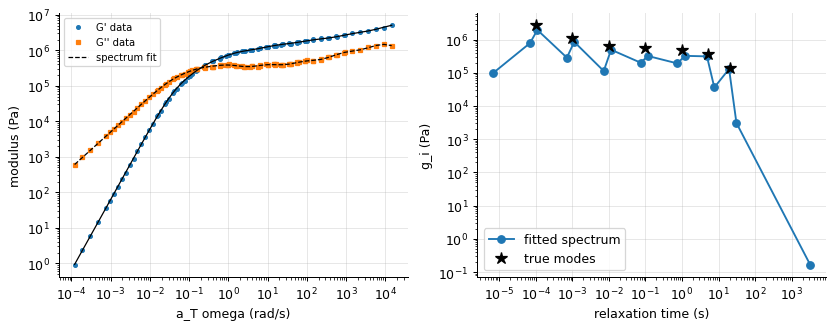

51 modes on the grid, 16 non-zero; rms misfit 2.1 %
eta0: fit 4.996e+06 Pa s, true 5.057e+06 Pa s
Je0:  fit 2.54e-06 1/Pa, true 2.48e-06 1/Pa


In [2]:
melt = pd.read_csv(datasets.path("polystyrene_frequency_sweeps.csv"), comment="#")
curves = {T_C + 273.15: (g.omega_rad_s.to_numpy(), g[["G_storage_Pa", "G_loss_Pa"]].to_numpy()) for T_C, g in melt.groupby("temperature_C")}
mc = tts.master_curve(curves, 443.15)
w = np.concatenate([mc["omega_reduced"][T_] for T_ in sorted(curves)])
Y = np.vstack([mc["y"][T_] for T_ in sorted(curves)])
o = np.argsort(w); w, Gp, Gpp = w[o], Y[o, 0], Y[o, 1]
fit = ve.fit_spectrum(w, Gp, Gpp)
g_true = np.array([2.7e6, 1.08e6, 6.3e5, 5.4e5, 4.95e5, 3.6e5, 1.35e5]); tau_true = np.array([1e-4, 1e-3, 1e-2, 1e-1, 1.0, 5.0, 20.0])
fp, fpp = fit.moduli(w)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
a1.loglog(w, Gp, "o", ms=3, label="G' data"); a1.loglog(w, Gpp, "s", ms=3, label="G'' data")
a1.loglog(w, fp, "k-", lw=1); a1.loglog(w, fpp, "k--", lw=1, label="spectrum fit")
a1.set(xlabel="a_T omega (rad/s)", ylabel="modulus (Pa)"); a1.legend(fontsize=8)
used = fit.g > 0
a2.loglog(fit.tau[used], fit.g[used], "o-", label="fitted spectrum")
a2.loglog(tau_true, g_true, "k*", ms=10, label="true modes")
a2.set(xlabel="relaxation time (s)", ylabel="g_i (Pa)"); a2.legend()
plt.show()
print(f"{fit.tau.size} modes on the grid, {used.sum()} non-zero; rms misfit {100*fit.rel_rms:.1f} %")
print(f"eta0: fit {fit.eta0:.4g} Pa s, true {ve.zero_shear_viscosity(g_true, tau_true):.4g} Pa s")
print(f"Je0:  fit {ve.steady_state_compliance(fit.g, fit.tau):.3g} 1/Pa, true {ve.steady_state_compliance(g_true, tau_true):.3g} 1/Pa")

The spectrum reproduces the data within their scatter, and the zero-shear viscosity and steady-state
compliance agree with the true values. The individual modes, however, look nothing like the true seven
modes - and that is not a failure of the fit.

## Many spectra, one data set

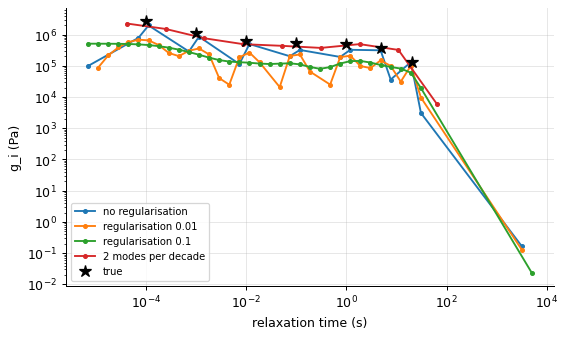

no regularisation   : misfit  2.1 %, eta0 4.996e+06 Pa s, Je0 2.54e-06 1/Pa
regularisation 0.01 : misfit  2.3 %, eta0 4.993e+06 Pa s, Je0 2.54e-06 1/Pa
regularisation 0.1  : misfit  2.9 %, eta0 4.985e+06 Pa s, Je0 2.54e-06 1/Pa
2 modes per decade  : misfit  4.5 %, eta0 4.936e+06 Pa s, Je0 2.65e-06 1/Pa


In [3]:
fits = {"no regularisation": ve.fit_spectrum(w, Gp, Gpp),
        "regularisation 0.01": ve.fit_spectrum(w, Gp, Gpp, regularization=0.01),
        "regularisation 0.1": ve.fit_spectrum(w, Gp, Gpp, regularization=0.1),
        "2 modes per decade": ve.fit_spectrum(w, Gp, Gpp, n_modes=int(2 * 7))}
fig, ax = plt.subplots()
for name, f in fits.items():
    ax.loglog(f.tau[f.g > 0], f.g[f.g > 0], "o-", ms=3, label=name)
ax.loglog(tau_true, g_true, "k*", ms=10, label="true")
ax.set(xlabel="relaxation time (s)", ylabel="g_i (Pa)"); ax.legend(fontsize=8); plt.show()
for name, f in fits.items():
    print(f"{name:<20}: misfit {100*f.rel_rms:4.1f} %, eta0 {f.eta0:.4g} Pa s, Je0 {ve.steady_state_compliance(f.g, f.tau):.3g} 1/Pa")

Very different spectra reproduce the same data almost equally well: the data determine the spectrum only
in an averaged, smoothed sense. Regularisation chooses the smoothest among the acceptable spectra at the
cost of a slightly larger misfit. What is robust are the **integral properties** - the zero-shear viscosity
(the first moment) and the steady-state compliance - and the moduli themselves within the measured
frequency range. Never interpret individual modes as molecular relaxation processes, and never trust a
spectrum outside the frequency range of the data.

## Using the spectrum
Once fitted, the spectrum predicts any linear response - here the relaxation modulus and the creep
compliance, compared with those of the true spectrum:

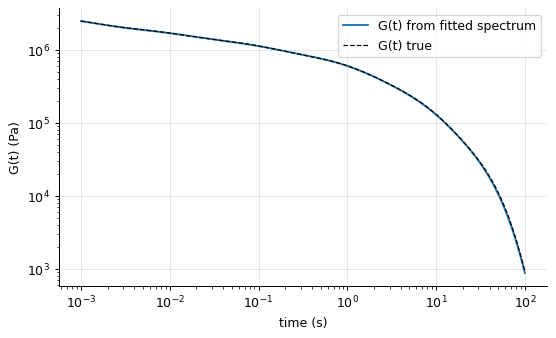

max relative error of G(t) for 1/omega_max < t < 1/omega_min: 5.9%


In [4]:
t = np.logspace(-3, 2, 200)
plt.loglog(t, fit.relaxation(t), label="G(t) from fitted spectrum")
plt.loglog(t, ve.relaxation_modulus(g_true, tau_true, t), "k--", lw=1, label="G(t) true")
plt.xlabel("time (s)"); plt.ylabel("G(t) (Pa)"); plt.legend(); plt.show()
inside = (t > 1 / w.max()) & (t < 1 / w.min())
print(f"max relative error of G(t) for 1/omega_max < t < 1/omega_min: "
      f"{np.max(np.abs(fit.relaxation(t[inside]) / ve.relaxation_modulus(g_true, tau_true, t[inside]) - 1)):.1%}")

Within the time window corresponding to the measured frequencies, the prediction agrees with the truth to
within about 6 %, even though the modes themselves differ: the spectrum is a good *model* of the
material, not a unique description of it.

## Inside the algorithm: non-negative least squares on a fixed grid
With the relaxation times fixed, $G'$ and $G''$ are *linear* in the $g_i$. Dividing each equation by the measured
value makes the residuals relative; `scipy.optimize.nnls` then finds the best $g_i \ge 0$:

In [5]:
from scipy.optimize import nnls
tau_grid = np.logspace(-5, 3, 25)
wt = w[:, None] * tau_grid
A = np.vstack([wt**2 / (1 + wt**2) / Gp[:, None], wt / (1 + wt**2) / Gpp[:, None]])
g_hand, _ = nnls(A, np.ones(2 * w.size), maxiter=5000)
lib = ve.fit_spectrum(w, Gp, Gpp, tau=tau_grid)
print(f"by hand: eta0 {np.sum(g_hand*tau_grid):.5g} Pa s;  library (same grid): {lib.eta0:.5g} Pa s")

by hand: eta0 4.9933e+06 Pa s;  library (same grid): 4.9933e+06 Pa s


## Exercises
1. Remove all data below 1 rad/s (reduced frequency) and refit. How do the fitted zero-shear viscosity and steady-state compliance change, and why?
2. Fit spectra with 1, 2, 5 and 10 modes per decade. How does the misfit change, and from which density on does adding modes stop helping?
3. **Implement it yourself:** compute the steady-state compliance $J_e^0 = \sum g_i\tau_i^2/(\sum g_i\tau_i)^2$ from the fitted spectrum by hand, and check it against the long-time behaviour of the creep compliance from `ve.creep_from_relaxation` ($J(t) \to J_e^0 + t/\eta_0$).